# 翻前范围预测与可视化

本 Notebook 演示如何使用 `OpponentRangePredictor` 预测对手的翻前范围，并将结果可视化为 13x13 的热力图。

## 场景描述

我们将复现以下 6-max 场景：
1.  **Hero** 在 **BTN** 位置。
2.  **UTG** 弃牌 (Fold)。
3.  **MP** 平跟 (Call/Limp)。
4.  **CO** 弃牌 (Fold)。

目标是预测并绘制 **MP** 玩家在做出平跟动作后的手牌范围。

In [1]:
import logging
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections.abc import Sequence

# 设置项目路径
project_root = Path.cwd().parent.parent.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"项目根目录: {project_root}")
print(f"src 路径: {src_path}")

# 配置日志
logging.basicConfig(level=logging.INFO)

# 导入业务模块
from bayes_poker.domain.poker import ActionType, Street
from bayes_poker.player_metrics.enums import TableType
from bayes_poker.strategy.opponent_range import (
    OpponentRangePredictor,
    create_opponent_range_predictor,
)
from bayes_poker.strategy.preflop_parse.parser import parse_strategy_directory
from bayes_poker.strategy.range import RANGE_169_ORDER
from bayes_poker.storage.player_stats_repository import PlayerStatsRepository
from bayes_poker.table.observed_state import (
    Player,
    ObservedTableState,
    PlayerAction,
)

项目根目录: /home/autumn
src 路径: /home/autumn/src


## 1. 定义可视化工具

我们需要一个函数将 169 维的策略向量转换为扑克手牌矩阵（13x13）并绘制热力图。
- **对角线**：对子 (22-AA)
- **右上三角**：同花 (s)
- **左下三角**：非同花 (o)

In [2]:
def plot_range_13x13(strategy: list[float], title: str = "Range Heatmap") -> None:
    """绘制 13x13 手牌范围热力图。"""
    ranks = "AKQJT98765432"
    grid = np.zeros((13, 13))
    
    # 构建 rank 到索引的映射 (A=0, K=1, ... 2=12)
    rank_to_idx = {r: i for i, r in enumerate(ranks)}
    
    # 填充网格
    for idx, freq in enumerate(strategy):
        hand_key = RANGE_169_ORDER[idx]
        
        if len(hand_key) == 2:  # 对子, 如 "AA"
            r1 = hand_key[0]
            i = rank_to_idx[r1]
            grid[i, i] = freq
        elif hand_key.endswith("s"):  # 同花, 如 "AKs"
            r1, r2 = hand_key[0], hand_key[1]
            i, j = rank_to_idx[r1], rank_to_idx[r2]
            # 同花在右上三角 (行 < 列)
            # 注意: RANGE_169_ORDER 中大牌在前, rank_to_idx 中大牌索引小
            # 例如 AKs: A(0), K(1) -> grid[0, 1]
            if i > j: i, j = j, i
            grid[i, j] = freq
        elif hand_key.endswith("o"):  # 非同花, 如 "AKo"
            r1, r2 = hand_key[0], hand_key[1]
            i, j = rank_to_idx[r1], rank_to_idx[r2]
            # 非同花在左下三角 (行 > 列)
            # 例如 AKo: A(0), K(1) -> grid[1, 0]
            if i < j: i, j = j, i
            grid[i, j] = freq
            
    # 绘制热力图
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        grid, 
        xticklabels=list(ranks), 
        yticklabels=list(ranks), 
        cmap="viridis",
        vmin=0.0, 
        vmax=1.0,
        linewidths=0.5,
        linecolor='gray',
        square=True,
        cbar_kws={'label': 'Frequency'}
    )
    plt.title(title)
    plt.ylabel("Rank 1")
    plt.xlabel("Rank 2")
    plt.show()

## 2. 初始化预测器

加载真实策略文件和统计数据库。

In [4]:
# 定义路径
REAL_PRELFOP_STRATEGY_DIR = Path(
    "/home/autumn/project/gg_handhistory/preflop_strategy/Cash6m50zSimple25Open_SimpleIP"
)
REAL_PLAYER_STATS_DB_PATH = Path("/home/autumn/project/bayes_poker/data/database/player_stats.db")

# 检查路径存在
if not REAL_PRELFOP_STRATEGY_DIR.is_dir():
    raise FileNotFoundError(f"策略目录不存在: {REAL_PRELFOP_STRATEGY_DIR}")
if not REAL_PLAYER_STATS_DB_PATH.is_file():
    raise FileNotFoundError(f"统计数据库不存在: {REAL_PLAYER_STATS_DB_PATH}")

# 加载策略
print("正在加载翻前策略...")
preflop_strategy = parse_strategy_directory(REAL_PRELFOP_STRATEGY_DIR)
print(f"策略加载完成，节点数: {preflop_strategy.node_count()}")

# 连接数据库
print("正在连接统计数据库...")
stats_repo = PlayerStatsRepository(REAL_PLAYER_STATS_DB_PATH)
stats_repo.connect()

# 创建预测器
predictor = create_opponent_range_predictor(
    preflop_strategy=preflop_strategy,
    stats_repo=stats_repo,
    table_type=TableType.SIX_MAX,
)
print("预测器初始化完成")

INFO:bayes_poker.strategy.preflop_parse.parser:开始解析策略 Cash6m50zSimple25Open_SimpleIP，共 897 个文件


正在加载翻前策略...


INFO:bayes_poker.strategy.preflop_parse.parser:策略 Cash6m50zSimple25Open_SimpleIP 解析完成：897 个文件，897 个节点


策略加载完成，节点数: 897
正在连接统计数据库...
预测器初始化完成


## 3. 构建场景 & 执行动作

**场景**: 6-max, Hero @ BTN
**动作序列**: 
1. UTG Fold
2. MP Call (分析目标)

In [5]:
def build_sixmax_players_with_hero_btn() -> list[Player]:
    """构建 Hero 在 BTN 的 6-max 玩家列表。"""
    # 0: BTN (Hero)
    # 1: SB
    # 2: BB
    # 3: UTG
    # 4: MP
    # 5: CO
    return [
        Player(seat_index=0, player_id="hero", position="BTN", stack=100.0),
        Player(seat_index=1, player_id="sb", position="SB", stack=100.0),
        Player(seat_index=2, player_id="bb", position="BB", stack=100.0),
        Player(seat_index=3, player_id="utg", position="UTG", stack=100.0),
        Player(seat_index=4, player_id="mp", position="MP", stack=100.0),
        Player(seat_index=5, player_id="co", position="CO", stack=100.0),
    ]

players = build_sixmax_players_with_hero_btn()

# 初始状态
table_state = ObservedTableState(
    player_count=6,
    btn_seat=0,
    hero_seat=0,
    street=Street.PREFLOP,
    big_blind=1.0,
    players=players,
)

# 动作序列
actions = [
    PlayerAction(
        player_index=3,  # UTG
        action_type=ActionType.FOLD,
        amount=0.0,
        street=Street.PREFLOP,
    ),
    PlayerAction(
        player_index=4,  # MP
        action_type=ActionType.CALL,
        amount=1.0,
        street=Street.PREFLOP,
    ),
]

# 执行预测更新
print("开始执行动作...")
for idx, action in enumerate(actions):
    player = players[action.player_index]
    print(f"动作 {idx+1}: {player.position} {action.action_type.name} {action.amount}")
    
    predictor.update_range_on_action(
        player,
        action,
        table_state,
        action_prefix=actions[:idx],  # 传入之前的所有动作作为前缀
    )

开始执行动作...
动作 1: UTG FOLD 0.0
动作 2: MP CALL 1.0


## 4. 可视化结果

获取 MP (Seat 4) 的翻前范围并绘制。

MP Range Total Frequency: 1.0000


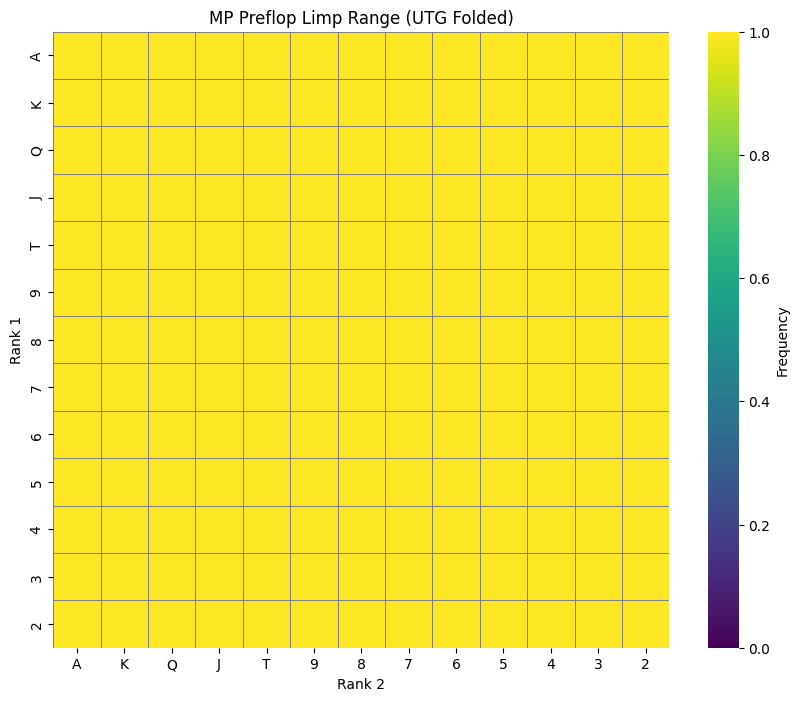

In [6]:
mp_seat_index = 4
mp_range = predictor.get_preflop_range(mp_seat_index)

if mp_range:
    print(f"MP Range Total Frequency: {mp_range.total_frequency():.4f}")
    plot_range_13x13(mp_range.strategy, title="MP Preflop Limp Range (UTG Folded)")
else:
    print("未找到 MP 的范围预测结果。")

## 5. 清理资源

In [ ]:
stats_repo.close()
print("数据库连接已关闭")